In [1]:
# ============================================================
# Get Fit with Drishti
# Phase 5 Part C: Word of Mouth Score
# Step 1: Create Superfan Score base table
# ============================================================

# Import pandas for data analysis
import pandas as pd

# Import numpy for conditional scoring
import numpy as np


# ------------------------------------------------------------
# 1. Load the cleaned dataset
# ------------------------------------------------------------

# Load cleaned data from the cleaned data folder
df = pd.read_csv("../02_cleaned_data/Drishti_Clean_Data.csv")

# Show dataset size
print("Dataset shape:")
print(df.shape)


# ------------------------------------------------------------
# 2. Create Referred_Someone flag
# ------------------------------------------------------------

# A client referred someone if their Client_ID appears in the Referred_By column
referrer_ids = df["Referred_By"].dropna().unique()

# 1 = this client referred at least one other client
# 0 = this client did not refer anyone
df["Referred_Someone"] = np.where(
    df["Client_ID"].isin(referrer_ids),
    1,
    0
)

# Check how many clients referred someone
print("\nClients who referred someone:")
print(df["Referred_Someone"].value_counts())


# ------------------------------------------------------------
# 3. Create Goal_Achieved score
# ------------------------------------------------------------

# Goal_Achieved scoring:
# Yes = 3 points
# Partial = 1 point
# No or Ongoing = 0 points
df["Goal_Achieved_Score"] = df["Goal_Achieved"].map({
    "Yes": 3,
    "Partial": 1,
    "No": 0,
    "Ongoing": 0
}).fillna(0)


# ------------------------------------------------------------
# 4. Create Checkin score
# ------------------------------------------------------------

# Checkin_Rate_Pct is already 0 to 100
# Normalize it to a 0 to 2 point score
df["Checkin_Score"] = (df["Checkin_Rate_Pct"] / 100) * 2

# Round to 2 decimals
df["Checkin_Score"] = df["Checkin_Score"].round(2)


# ------------------------------------------------------------
# 5. Create Progress Photos score
# ------------------------------------------------------------

# Progress_Photos_Shared:
# Yes = 1 point
# No = 0 points
df["Progress_Photos_Score"] = np.where(
    df["Progress_Photos_Shared"] == "Yes",
    1,
    0
)


# ------------------------------------------------------------
# 6. Create Second Round score
# ------------------------------------------------------------

# Second_Round:
# Yes = 2 points
# No = 0 points
df["Second_Round_Score"] = np.where(
    df["Second_Round"] == "Yes",
    2,
    0
)


# ------------------------------------------------------------
# 7. Create Referral score
# ------------------------------------------------------------

# Referred_Someone:
# Yes = 2 points
# No = 0 points
df["Referral_Score"] = np.where(
    df["Referred_Someone"] == 1,
    2,
    0
)


# ------------------------------------------------------------
# 8. Calculate final Superfan Score
# ------------------------------------------------------------

# Total possible score = 10
df["Superfan_Score"] = (
    df["Goal_Achieved_Score"] +
    df["Checkin_Score"] +
    df["Progress_Photos_Score"] +
    df["Second_Round_Score"] +
    df["Referral_Score"]
)

# Round final score to 2 decimals
df["Superfan_Score"] = df["Superfan_Score"].round(2)


# ------------------------------------------------------------
# 9. Create Superfan Segment
# ------------------------------------------------------------

# Function to assign segment based on score
def assign_superfan_segment(score):
    if score >= 8:
        return "Superfan"
    elif score >= 5:
        return "Happy"
    elif score >= 3:
        return "Neutral"
    else:
        return "At Risk"


# Apply the segment function
df["Superfan_Segment"] = df["Superfan_Score"].apply(assign_superfan_segment)


# ------------------------------------------------------------
# 10. Review score distribution
# ------------------------------------------------------------

# Count clients in each segment
segment_summary = (
    df["Superfan_Segment"]
    .value_counts()
    .reset_index()
)

segment_summary.columns = ["Superfan_Segment", "Client_Count"]

# Add percentage
segment_summary["Percentage"] = (
    segment_summary["Client_Count"] / len(df) * 100
).round(2)

print("\nSuperfan segment summary:")
print(segment_summary)


# ------------------------------------------------------------
# 11. Preview final scoring table
# ------------------------------------------------------------

# Select important columns to preview
superfan_score_preview = df[
    [
        "Client_ID",
        "Goal_Achieved",
        "Goal_Achieved_Score",
        "Checkin_Rate_Pct",
        "Checkin_Score",
        "Progress_Photos_Shared",
        "Progress_Photos_Score",
        "Second_Round",
        "Second_Round_Score",
        "Referred_Someone",
        "Referral_Score",
        "Superfan_Score",
        "Superfan_Segment"
    ]
].head(10)

print("\nSuperfan score preview:")
superfan_score_preview

Dataset shape:
(3000, 40)

Clients who referred someone:
Referred_Someone
0    2319
1     681
Name: count, dtype: int64

Superfan segment summary:
  Superfan_Segment  Client_Count  Percentage
0            Happy          1497       49.90
1          Neutral           802       26.73
2          At Risk           574       19.13
3         Superfan           127        4.23

Superfan score preview:


,Client_ID,Goal_Achieved,Goal_Achieved_Score,Checkin_Rate_Pct,Checkin_Score,Progress_Photos_Shared,Progress_Photos_Score,Second_Round,Second_Round_Score,Referred_Someone,Referral_Score,Superfan_Score,Superfan_Segment
0,C0001,Partial,1,100.0,2.00,Yes,1,No,0,0,0,4.00,Neutral
1,C0002,No,0,7.1,0.14,Yes,1,No,0,0,0,1.14,At Risk
2,C0003,Partial,1,78.6,1.57,Yes,1,No,0,1,2,5.57,Happy
3,C0004,Yes,3,100.0,2.00,Yes,1,No,0,1,2,8.00,Superfan
4,C0005,No,0,0.0,0.00,No,0,No,0,1,2,2.00,At Risk
5,C0006,Partial,1,100.0,2.00,Yes,1,No,0,1,2,6.00,Happy
6,C0007,No,0,7.1,0.14,No,0,No,0,0,0,0.14,At Risk
7,C0008,Yes,3,78.6,1.57,Yes,1,No,0,0,0,5.57,Happy
8,C0009,Partial,1,85.7,1.71,Yes,1,Yes,2,0,0,5.71,Happy
9,C0010,Ongoing,0,14.3,0.29,No,0,No,0,1,2,2.29,At Risk


Superfan Score distribution:
    Superfan_Score  Client_Count  Percentage
0                0           180        6.00
1                1           102        3.40
2                2           185        6.17
3                3           164        5.47
4                4           550       18.33
5                5           271        9.03
6                6          1082       36.07
7                7            86        2.87
8                8           345       11.50
9                9             6        0.20
10              10            29        0.97


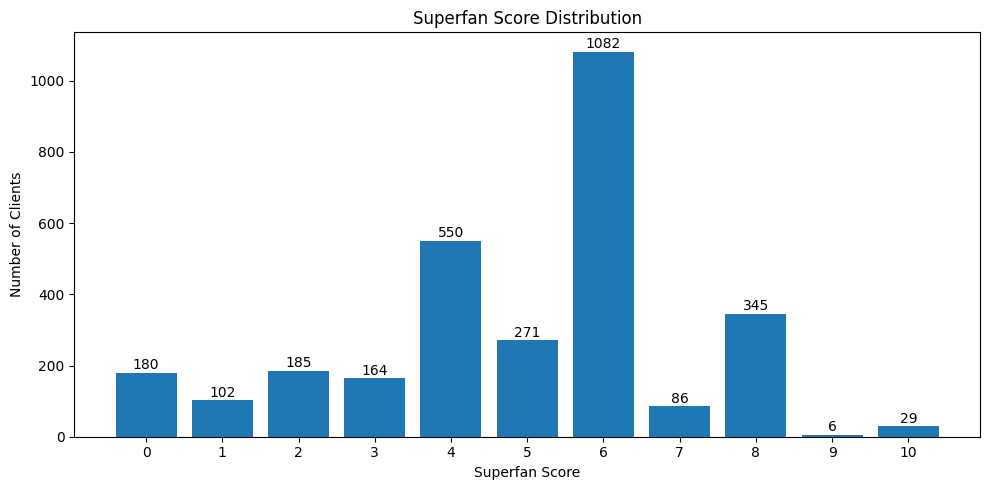

In [2]:
# ============================================================
# Phase 5 Part C
# Step 2: Visualize Superfan Score distribution
# ============================================================

# Import matplotlib for charting
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# 1. Create score distribution table
# ------------------------------------------------------------

# Round Superfan Score to nearest whole number for easier business interpretation
df["Superfan_Score_Rounded"] = df["Superfan_Score"].round(0).astype(int)

# Count clients at each rounded score
score_distribution = (
    df["Superfan_Score_Rounded"]
    .value_counts()
    .sort_index()
    .reset_index()
)

# Rename columns clearly
score_distribution.columns = ["Superfan_Score", "Client_Count"]

# Add percentage of total clients
score_distribution["Percentage"] = (
    score_distribution["Client_Count"] / len(df) * 100
).round(2)

print("Superfan Score distribution:")
print(score_distribution)


# ------------------------------------------------------------
# 2. Create bar chart of score distribution
# ------------------------------------------------------------

# Create chart canvas
plt.figure(figsize=(10, 5))

# Create bar chart
plt.bar(
    score_distribution["Superfan_Score"].astype(str),
    score_distribution["Client_Count"]
)

# Add chart title and axis labels
plt.title("Superfan Score Distribution")
plt.xlabel("Superfan Score")
plt.ylabel("Number of Clients")

# Add count labels on top of each bar
for index, value in enumerate(score_distribution["Client_Count"]):
    plt.text(index, value + 10, str(value), ha="center")

# Make layout clean
plt.tight_layout()

# Show chart
plt.show()

Superfan vs Everyone Else comparison:
  Superfan_Group  Client_Count  Avg_Superfan_Score  Goal_Success_Rate_Pct  \
1       Superfan           127                8.44                 100.00   
0  Everyone Else          2873                4.58                  80.19   

   Avg_Checkin_Rate_Pct  Progress_Photos_Rate_Pct  Second_Round_Rate_Pct  \
1                 96.80                     95.28                  45.67   
0                 73.95                     66.13                  12.88   

   Referred_Someone_Rate_Pct  
1                      85.04  
0                      19.94  

Chart data preview:
  Superfan_Group                  Metric  Percentage
0       Superfan            Goal Success      100.00
1  Everyone Else            Goal Success       80.19
2       Superfan       Avg Check-In Rate       96.80
3  Everyone Else       Avg Check-In Rate       73.95
4       Superfan  Progress Photos Shared       95.28
5  Everyone Else  Progress Photos Shared       66.13
6       Superfan

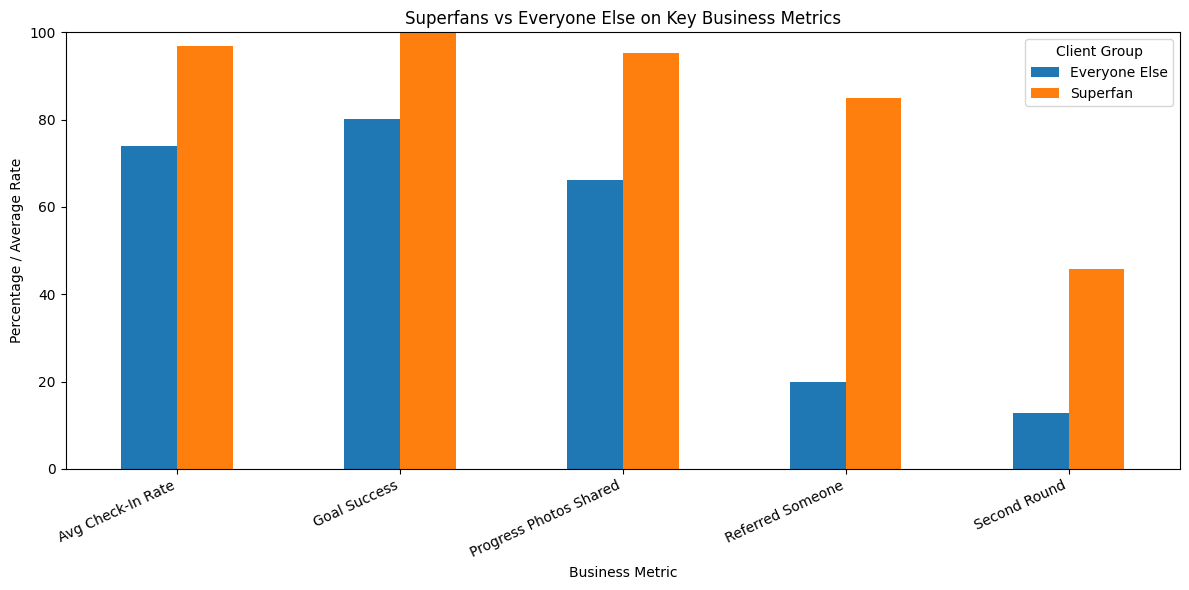

In [3]:
# ============================================================
# Phase 5 Part C
# Step 3: Compare Superfans vs everyone else
# ============================================================

# ------------------------------------------------------------
# 1. Create Superfan vs Everyone Else group
# ------------------------------------------------------------

# Superfan = clients with Superfan_Segment equal to "Superfan"
# Everyone Else = all other clients
df["Superfan_Group"] = np.where(
    df["Superfan_Segment"] == "Superfan",
    "Superfan",
    "Everyone Else"
)


# ------------------------------------------------------------
# 2. Create business metric flags
# ------------------------------------------------------------

# Success means client achieved goal fully or partially
df["Goal_Success_Flag"] = np.where(
    df["Goal_Achieved"].isin(["Yes", "Partial"]),
    1,
    0
)

# Progress photo flag
df["Progress_Photos_Flag"] = np.where(
    df["Progress_Photos_Shared"] == "Yes",
    1,
    0
)

# Second round flag
df["Second_Round_Flag"] = np.where(
    df["Second_Round"] == "Yes",
    1,
    0
)

# Referral behavior flag already exists as Referred_Someone
# 1 = client referred someone else
# 0 = client did not refer someone else


# ------------------------------------------------------------
# 3. Build comparison table
# ------------------------------------------------------------

# Calculate average metrics by group
superfan_comparison = (
    df
    .groupby("Superfan_Group")
    .agg(
        Client_Count=("Client_ID", "count"),
        Avg_Superfan_Score=("Superfan_Score", "mean"),
        Goal_Success_Rate_Pct=("Goal_Success_Flag", lambda x: x.mean() * 100),
        Avg_Checkin_Rate_Pct=("Checkin_Rate_Pct", "mean"),
        Progress_Photos_Rate_Pct=("Progress_Photos_Flag", lambda x: x.mean() * 100),
        Second_Round_Rate_Pct=("Second_Round_Flag", lambda x: x.mean() * 100),
        Referred_Someone_Rate_Pct=("Referred_Someone", lambda x: x.mean() * 100)
    )
    .reset_index()
)

# Round numeric columns for clean presentation
numeric_cols = superfan_comparison.select_dtypes(include="number").columns
superfan_comparison[numeric_cols] = superfan_comparison[numeric_cols].round(2)

# Sort so Superfan appears first
superfan_comparison["Sort_Order"] = superfan_comparison["Superfan_Group"].map({
    "Superfan": 1,
    "Everyone Else": 2
})

superfan_comparison = (
    superfan_comparison
    .sort_values("Sort_Order")
    .drop(columns="Sort_Order")
)

print("Superfan vs Everyone Else comparison:")
print(superfan_comparison)


# ------------------------------------------------------------
# 4. Prepare chart data
# ------------------------------------------------------------

# Convert comparison table from wide to long format for charting
comparison_chart_df = superfan_comparison.melt(
    id_vars=["Superfan_Group"],
    value_vars=[
        "Goal_Success_Rate_Pct",
        "Avg_Checkin_Rate_Pct",
        "Progress_Photos_Rate_Pct",
        "Second_Round_Rate_Pct",
        "Referred_Someone_Rate_Pct"
    ],
    var_name="Metric",
    value_name="Percentage"
)

# Make metric names easier to read
comparison_chart_df["Metric"] = comparison_chart_df["Metric"].replace({
    "Goal_Success_Rate_Pct": "Goal Success",
    "Avg_Checkin_Rate_Pct": "Avg Check-In Rate",
    "Progress_Photos_Rate_Pct": "Progress Photos Shared",
    "Second_Round_Rate_Pct": "Second Round",
    "Referred_Someone_Rate_Pct": "Referred Someone"
})

print("\nChart data preview:")
print(comparison_chart_df)


# ------------------------------------------------------------
# 5. Create comparison bar chart
# ------------------------------------------------------------

# Pivot data for grouped bar chart
comparison_pivot = comparison_chart_df.pivot(
    index="Metric",
    columns="Superfan_Group",
    values="Percentage"
)

# Create grouped bar chart
ax = comparison_pivot.plot(
    kind="bar",
    figsize=(12, 6)
)

# Add chart title and labels
plt.title("Superfans vs Everyone Else on Key Business Metrics")
plt.xlabel("Business Metric")
plt.ylabel("Percentage / Average Rate")

# Rotate x-axis labels
plt.xticks(rotation=25, ha="right")

# Keep y-axis between 0 and 100
plt.ylim(0, 100)

# Add legend title
plt.legend(title="Client Group")

# Make layout clean
plt.tight_layout()

# Show chart
plt.show()

In [4]:
# ============================================================
# Phase 5 Part C
# Step 4: Identify the biggest Superfan behavior gaps
# ============================================================

# ------------------------------------------------------------
# 1. Create a clean comparison table for gap analysis
# ------------------------------------------------------------

# Keep only the 5 main Superfan metrics
gap_table = superfan_comparison[
    [
        "Superfan_Group",
        "Goal_Success_Rate_Pct",
        "Avg_Checkin_Rate_Pct",
        "Progress_Photos_Rate_Pct",
        "Second_Round_Rate_Pct",
        "Referred_Someone_Rate_Pct"
    ]
].copy()

# Set Superfan_Group as index so we can compare rows easily
gap_table = gap_table.set_index("Superfan_Group")

# Calculate the gap between Superfans and Everyone Else
superfan_gap = (
    gap_table.loc["Superfan"] - gap_table.loc["Everyone Else"]
).reset_index()

# Rename columns clearly
superfan_gap.columns = ["Metric", "Superfan_Gap_Pct_Points"]

# Make metric names easier to read
superfan_gap["Metric"] = superfan_gap["Metric"].replace({
    "Goal_Success_Rate_Pct": "Goal Success",
    "Avg_Checkin_Rate_Pct": "Average Check-In Rate",
    "Progress_Photos_Rate_Pct": "Progress Photos Shared",
    "Second_Round_Rate_Pct": "Second Round Signup",
    "Referred_Someone_Rate_Pct": "Referred Someone"
})

# Round gap values
superfan_gap["Superfan_Gap_Pct_Points"] = superfan_gap["Superfan_Gap_Pct_Points"].round(2)

# Sort by biggest gap
superfan_gap = superfan_gap.sort_values(
    by="Superfan_Gap_Pct_Points",
    ascending=False
)

print("Superfan behavior gap table:")
print(superfan_gap)


# ------------------------------------------------------------
# 2. Select the top 3 Superfan drivers
# ------------------------------------------------------------

# These are the 3 metrics where Superfans are most different from everyone else
top_3_superfan_drivers = superfan_gap.head(3).copy()

print("\nTop 3 Superfan drivers:")
print(top_3_superfan_drivers)


# ------------------------------------------------------------
# 3. Add action recommendations
# ------------------------------------------------------------

# Function to create business actions for each driver
def superfan_action(metric):
    if metric == "Referred Someone":
        return "Ask happy clients for referrals right after visible progress or a strong check-in."
    elif metric == "Second Round Signup":
        return "Offer a second-round plan before the first program ends, especially to high-engagement clients."
    elif metric == "Progress Photos Shared":
        return "Create progress photo reminders and celebrate client transformations with permission."
    elif metric == "Average Check-In Rate":
        return "Use weekly check-in nudges and make check-ins easy, quick, and encouraging."
    elif metric == "Goal Success":
        return "Keep clients focused on small realistic milestones that lead to visible progress."
    else:
        return "Create a simple repeatable action to improve this behavior."

# Add recommendations
top_3_superfan_drivers["How Drishti Can Create More"] = top_3_superfan_drivers["Metric"].apply(superfan_action)

print("\nTop 3 Superfan drivers with actions:")
top_3_superfan_drivers

Superfan behavior gap table:
                   Metric  Superfan_Gap_Pct_Points
4        Referred Someone                    65.10
3     Second Round Signup                    32.79
2  Progress Photos Shared                    29.15
1   Average Check-In Rate                    22.85
0            Goal Success                    19.81

Top 3 Superfan drivers:
                   Metric  Superfan_Gap_Pct_Points
4        Referred Someone                    65.10
3     Second Round Signup                    32.79
2  Progress Photos Shared                    29.15

Top 3 Superfan drivers with actions:


,Metric,Superfan_Gap_Pct_Points,How Drishti Can Create More
4,Referred Someone,65.10,Ask happy clients for referrals right after vi...
3,Second Round Signup,32.79,Offer a second-round plan before the first pro...
2,Progress Photos Shared,29.15,Create progress photo reminders and celebrate ...


In [5]:
# ============================================================
# Phase 5 Part C
# Step 5: Save Word of Mouth Score output files
# ============================================================

# Import os to create folders and save files
import os

# ------------------------------------------------------------
# 1. Create output folder for Phase 5 Part C
# ------------------------------------------------------------

# Set output folder path
output_folder = "../05_outputs/phase5_word_of_mouth_score"

# Create the folder if it does not already exist
os.makedirs(output_folder, exist_ok=True)

print("Output folder ready:")
print(output_folder)


# ------------------------------------------------------------
# 2. Create final scored client table
# ------------------------------------------------------------

# Keep useful columns for dashboard, report, and future business use
superfan_scored_clients = df[
    [
        "Client_ID",
        "Age",
        "Gender",
        "Country",
        "Goal_Type",
        "Lead_Source",
        "Goal_Achieved",
        "Checkin_Rate_Pct",
        "Progress_Photos_Shared",
        "Second_Round",
        "Referred_Someone",
        "Goal_Achieved_Score",
        "Checkin_Score",
        "Progress_Photos_Score",
        "Second_Round_Score",
        "Referral_Score",
        "Superfan_Score",
        "Superfan_Score_Rounded",
        "Superfan_Segment"
    ]
].copy()


# ------------------------------------------------------------
# 3. Save all Part C output tables
# ------------------------------------------------------------

# Save scored client-level table
superfan_scored_clients.to_csv(
    f"{output_folder}/superfan_scored_clients.csv",
    index=False
)

# Save segment summary from Step 1
segment_summary.to_csv(
    f"{output_folder}/superfan_segment_summary.csv",
    index=False
)

# Save score distribution from Step 2
score_distribution.to_csv(
    f"{output_folder}/superfan_score_distribution.csv",
    index=False
)

# Save Superfan vs Everyone Else comparison from Step 3
superfan_comparison.to_csv(
    f"{output_folder}/superfan_vs_everyone_comparison.csv",
    index=False
)

# Save top 3 Superfan drivers from Step 4
top_3_superfan_drivers.to_csv(
    f"{output_folder}/top_3_superfan_drivers.csv",
    index=False
)


# ------------------------------------------------------------
# 4. Confirm saved files
# ------------------------------------------------------------

print("\nPhase 5 Part C files saved successfully.")
print("Saved folder:", output_folder)

print("\nSaved files:")
print("- superfan_scored_clients.csv")
print("- superfan_segment_summary.csv")
print("- superfan_score_distribution.csv")
print("- superfan_vs_everyone_comparison.csv")
print("- top_3_superfan_drivers.csv")

Output folder ready:
../05_outputs/phase5_word_of_mouth_score

Phase 5 Part C files saved successfully.
Saved folder: ../05_outputs/phase5_word_of_mouth_score

Saved files:
- superfan_scored_clients.csv
- superfan_segment_summary.csv
- superfan_score_distribution.csv
- superfan_vs_everyone_comparison.csv
- top_3_superfan_drivers.csv
